# Lab 5.3. BERT как sentence embedder и semantic search

BERT создаёт contextual embeddings для каждого token: представление слова зависит от контекста предложения. Но многие прикладные задачи требуют одного vector для всего текста:

- поиск похожих предложений;
- semantic search по документам;
- clustering и визуализация текстов;
- поиск дубликатов;
- retrieval кандидатов перед более дорогим reranking.

В этой лабораторной мы последовательно построим такой pipeline и сравним **bi-encoder** с **CrossEncoder**.


## 1. Подготовка окружения

Модели загружаются с Hugging Face Hub при первом запуске. GPU ускоряет вычисления, но для небольших примеров достаточно CPU.


In [1]:
%%capture
!pip install -q transformers sentence-transformers scikit-learn seaborn


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

from sklearn.decomposition import PCA
from transformers import AutoModel, AutoTokenizer
from sentence_transformers import CrossEncoder, SentenceTransformer

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)


Устройство: cpu


## 2. От token embeddings к sentence embedding

После BERT каждый token представлен отдельным вектором размерности `hidden_size`. Чтобы получить один sentence embedding, нужно применить операцию  **pooling**, то есть усреднение.

Рассмотрим две простые стратегии:

- **CLS pooling** — берём представление специального token `[CLS]`;
- **mean pooling** — усредняем embeddings всех содержательных tokens с учётом `attention_mask`.

`attention_mask` необходим, чтобы padding tokens не влияли на среднее. После pooling обычно выполняют L2-нормализацию: тогда dot product совпадает с cosine similarity.


In [3]:
model_id = "DeepPavlov/rubert-base-cased-sentence"

tokenizer = AutoTokenizer.from_pretrained(model_id)
encoder = AutoModel.from_pretrained(model_id).to(device)
encoder.eval()

print("Размерность hidden state:", encoder.config.hidden_size)
print("Число encoder layers:", encoder.config.num_hidden_layers)


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/711M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Размерность hidden state: 768
Число encoder layers: 12


In [4]:
sentences = [
    "Этот город — лучший город на земле.",
    "Москва — столица России.",
    "Столица Российской Федерации находится в Москве.",
    "Лондон — столица Великобритании.",
    "Машинное обучение используется в обработке естественного языка.",
    "Современные NLP-системы часто основаны на машинном обучении.",
    "Сегодня в Москве ожидается сильный дождь.",
]

encoded = tokenizer(
    sentences,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt",
)
encoded = {name: tensor.to(device) for name, tensor in encoded.items()}

print("Форма input_ids:", tuple(encoded["input_ids"].shape))
print("Tokens первого предложения:")
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"][0]))


Форма input_ids: (7, 13)
Tokens первого предложения:
['[CLS]', 'Этот', 'город', '—', 'лучший', 'город', 'на', 'земле', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]']


In [5]:
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand_as(last_hidden_state).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def encode_with_bert(texts, pooling="mean", batch_size=16):
    batches = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]
        batch = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt",
        )
        batch = {name: tensor.to(device) for name, tensor in batch.items()}

        with torch.no_grad():
            output = encoder(**batch)

        if pooling == "mean":
            embeddings = mean_pooling(output.last_hidden_state, batch["attention_mask"])
        elif pooling == "cls":
            embeddings = output.last_hidden_state[:, 0]
        else:
            raise ValueError("pooling должен быть 'mean' или 'cls'")

        batches.append(F.normalize(embeddings, p=2, dim=1).cpu())

    return torch.cat(batches, dim=0)


mean_embeddings = encode_with_bert(sentences, pooling="mean")
cls_embeddings = encode_with_bert(sentences, pooling="cls")

print("Форма sentence embeddings:", tuple(mean_embeddings.shape))
print("L2-норма первого vector:", mean_embeddings[0].norm().item())


Форма sentence embeddings: (7, 768)
L2-норма первого vector: 1.0


## 3. Матрица semantic similarity

Вместо печати всех пар построим similarity matrix. Диагональ равна единице, поскольку каждое предложение полностью совпадает само с собой. Интерес представляют большие значения вне диагонали.

Сравним, как меняется картина при mean pooling и CLS pooling.


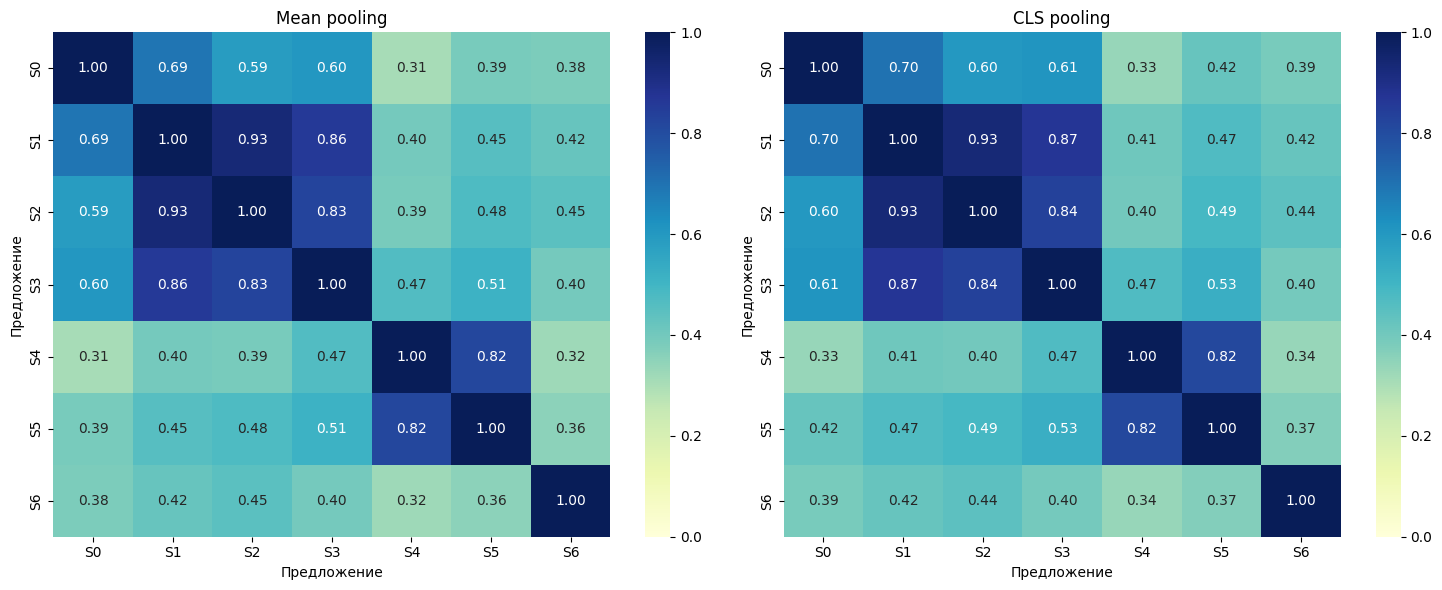

,ID,Предложение
0,S0,Этот город — лучший город на земле.
1,S1,Москва — столица России.
2,S2,Столица Российской Федерации находится в Москве.
3,S3,Лондон — столица Великобритании.
4,S4,Машинное обучение используется в обработке ест...
5,S5,Современные NLP-системы часто основаны на маши...
6,S6,Сегодня в Москве ожидается сильный дождь.


In [6]:
def plot_similarity_matrix(embeddings, labels, title, ax):
    similarities = embeddings @ embeddings.T
    sns.heatmap(
        similarities.numpy(),
        vmin=0,
        vmax=1,
        cmap="YlGnBu",
        annot=True,
        fmt=".2f",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Предложение")
    ax.set_ylabel("Предложение")
    return similarities


short_labels = [f"S{i}" for i in range(len(sentences))]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
mean_similarities = plot_similarity_matrix(
    mean_embeddings, short_labels, "Mean pooling", axes[0]
)
cls_similarities = plot_similarity_matrix(
    cls_embeddings, short_labels, "CLS pooling", axes[1]
)
plt.tight_layout()
plt.show()

display(pd.DataFrame({"ID": short_labels, "Предложение": sentences}))


In [7]:
def most_similar_pairs(similarity_matrix, texts, top_k=5):
    pairs = []
    for i in range(len(texts)):
        for j in range(i + 1, len(texts)):
            pairs.append((float(similarity_matrix[i, j]), texts[i], texts[j]))
    return sorted(pairs, key=lambda item: item[0], reverse=True)[:top_k]


for score, first, second in most_similar_pairs(mean_similarities, sentences):
    print(f"{score:.3f} | {first}\n        | {second}\n")


0.935 | Москва — столица России.
        | Столица Российской Федерации находится в Москве.

0.859 | Москва — столица России.
        | Лондон — столица Великобритании.

0.826 | Столица Российской Федерации находится в Москве.
        | Лондон — столица Великобритании.

0.818 | Машинное обучение используется в обработке естественного языка.
        | Современные NLP-системы часто основаны на машинном обучении.

0.693 | Этот город — лучший город на земле.
        | Москва — столица России.



### Обсуждение

Высокая cosine similarity не означает логическую эквивалентность. Она показывает близость представлений, выученных моделью. Результат зависит от предобучения, pooling-а и данных, на которых модель обучалась для sentence similarity.

У обычного BERT `[CLS]` обучался прежде всего как служебное представление на этапе предобучения. Поэтому CLS pooling не всегда оптимален без дополнительного contrastive learning. Модель `rubert-base-cased-sentence` уже адаптирована для sentence-level representation, но различия между pooling всё равно полезно проверить экспериментально.


## 4. Semantic search на русском языке

В semantic search запрос и документы кодируются в одно vector space. После этого документы ранжируются по cosine similarity с запросом.

Главное преимущество bi-encoder: embeddings документов можно вычислить заранее. Для нового запроса остаётся построить только один embedding и быстро найти ближайшие vectors.


In [8]:
corpus = [
    "Для оформления загранпаспорта подайте заявление через портал государственных услуг.",
    "Возврат билета возможен не позднее чем за два часа до отправления поезда.",
    "Чтобы восстановить пароль, нажмите ссылку в письме и придумайте новый пароль.",
    "Доставка заказа по Москве обычно занимает от одного до трёх рабочих дней.",
    "Нейронные сети обучаются с помощью алгоритма обратного распространения ошибки.",
    "Для смены адреса доставки откройте настройки активного заказа.",
    "Стоимость железнодорожного билета зависит от даты поездки и типа вагона.",
    "Если письмо для сброса пароля не пришло, проверьте папку со спамом.",
    "Паспорт можно получить в отделении МВД после уведомления о готовности.",
    "Курьер свяжется с вами перед приездом.",
]


def semantic_search(query, documents, document_embeddings, top_k=3):
    query_embedding = encode_with_bert([query], pooling="mean")
    scores = (query_embedding @ document_embeddings.T)[0]
    best_indices = torch.topk(scores, k=min(top_k, len(documents))).indices.tolist()
    return [(float(scores[index]), documents[index]) for index in best_indices]


corpus_embeddings = encode_with_bert(corpus, pooling="mean")

queries = [
    "Как поменять забытый пароль?",
    "Когда привезут мою покупку?",
    "Где забрать готовый заграничный паспорт?",
]

for query in queries:
    print(f"\nЗапрос: {query}")
    for score, document in semantic_search(query, corpus, corpus_embeddings):
        print(f"  {score:.3f} | {document}")



Запрос: Как поменять забытый пароль?
  0.838 | Если письмо для сброса пароля не пришло, проверьте папку со спамом.
  0.737 | Чтобы восстановить пароль, нажмите ссылку в письме и придумайте новый пароль.
  0.733 | Нейронные сети обучаются с помощью алгоритма обратного распространения ошибки.

Запрос: Когда привезут мою покупку?
  0.779 | Для смены адреса доставки откройте настройки активного заказа.
  0.727 | Курьер свяжется с вами перед приездом.
  0.718 | Стоимость железнодорожного билета зависит от даты поездки и типа вагона.

Запрос: Где забрать готовый заграничный паспорт?
  0.790 | Для оформления загранпаспорта подайте заявление через портал государственных услуг.
  0.786 | Чтобы восстановить пароль, нажмите ссылку в письме и придумайте новый пароль.
  0.756 | Паспорт можно получить в отделении МВД после уведомления о готовности.


## 5. SentenceTransformer: модель, специально обученная для similarity

`sentence-transformers` предоставляет готовые bi-encoder models, обученные с contrastive или ranking objective. Их API сразу возвращает sentence embeddings и скрывает tokenization и pooling.

Сравним ручной pipeline на RuBERT с компактной multilingual моделью на одних и тех же запросах. Сравнение здесь качественное: абсолютные similarity scores разных моделей нельзя напрямую интерпретировать как одну шкалу.


In [9]:
sentence_model_id = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
sentence_model = SentenceTransformer(sentence_model_id, device=str(device))

st_corpus_embeddings = sentence_model.encode(
    corpus,
    normalize_embeddings=True,
    convert_to_tensor=True,
)


def search_with_sentence_transformer(query, top_k=3):
    query_embedding = sentence_model.encode(
        query,
        normalize_embeddings=True,
        convert_to_tensor=True,
    )
    scores = sentence_model.similarity(query_embedding, st_corpus_embeddings)[0]
    indices = torch.topk(scores, k=top_k).indices.tolist()
    return [(float(scores[index]), corpus[index]) for index in indices]


for query in queries:
    print(f"\nЗапрос: {query}")
    print("RuBERT + mean pooling:")
    for score, document in semantic_search(query, corpus, corpus_embeddings, top_k=2):
        print(f"  {score:.3f} | {document}")
    print("Multilingual SentenceTransformer:")
    for score, document in search_with_sentence_transformer(query, top_k=2):
        print(f"  {score:.3f} | {document}")


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Запрос: Как поменять забытый пароль?
RuBERT + mean pooling:
  0.838 | Если письмо для сброса пароля не пришло, проверьте папку со спамом.
  0.737 | Чтобы восстановить пароль, нажмите ссылку в письме и придумайте новый пароль.
Multilingual SentenceTransformer:
  0.809 | Чтобы восстановить пароль, нажмите ссылку в письме и придумайте новый пароль.
  0.504 | Если письмо для сброса пароля не пришло, проверьте папку со спамом.

Запрос: Когда привезут мою покупку?
RuBERT + mean pooling:
  0.779 | Для смены адреса доставки откройте настройки активного заказа.
  0.727 | Курьер свяжется с вами перед приездом.
Multilingual SentenceTransformer:
  0.346 | Стоимость железнодорожного билета зависит от даты поездки и типа вагона.
  0.337 | Доставка заказа по Москве обычно занимает от одного до трёх рабочих дней.

Запрос: Где забрать готовый заграничный паспорт?
RuBERT + mean pooling:
  0.790 | Для оформления загранпаспорта подайте заявление через портал государственных услуг.
  0.786 | Чтобы восстан

## 6. Визуализация пространства embeddings

Sentence embeddings имеют сотни измерений. PCA проецирует их в двумерное пространство, сохраняя направления с наибольшей variance. Такая картинка полезна для исследования clusters и выбросов, но не доказывает качество модели: двумерная проекция неизбежно теряет информацию.


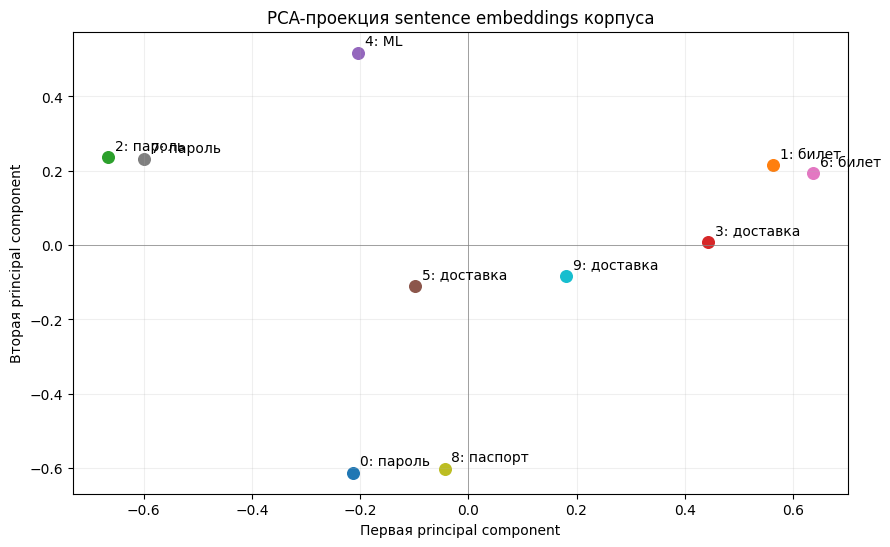

,ID,Тема,Документ
0,0,пароль,Для оформления загранпаспорта подайте заявлени...
1,1,билет,Возврат билета возможен не позднее чем за два ...
2,2,пароль,"Чтобы восстановить пароль, нажмите ссылку в пи..."
3,3,доставка,Доставка заказа по Москве обычно занимает от о...
4,4,ML,Нейронные сети обучаются с помощью алгоритма о...
5,5,доставка,Для смены адреса доставки откройте настройки а...
6,6,билет,Стоимость железнодорожного билета зависит от д...
7,7,пароль,"Если письмо для сброса пароля не пришло, прове..."
8,8,паспорт,Паспорт можно получить в отделении МВД после у...
9,9,доставка,Курьер свяжется с вами перед приездом.


In [10]:
topics = [
    "пароль", "билет", "пароль", "доставка", "ML",
    "доставка", "билет", "пароль", "паспорт", "доставка",
]

points = PCA(n_components=2).fit_transform(st_corpus_embeddings.cpu().numpy())

plt.figure(figsize=(10, 6))
for index, (x, y) in enumerate(points):
    plt.scatter(x, y, s=70)
    plt.annotate(f"{index}: {topics[index]}", (x, y), xytext=(5, 5), textcoords="offset points")

plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.title("PCA-проекция sentence embeddings корпуса")
plt.xlabel("Первая principal component")
plt.ylabel("Вторая principal component")
plt.grid(alpha=0.2)
plt.show()

display(pd.DataFrame({"ID": range(len(corpus)), "Тема": topics, "Документ": corpus}))


## 7. Bi-encoder и CrossEncoder

Bi-encoder кодирует запрос и документ независимо:

```text
query ──encoder──> q vector ─┐
                             ├── cosine similarity
doc   ──encoder──> d vector ─┘
```

CrossEncoder получает пару целиком: `[CLS] query [SEP] document [SEP]`. Благодаря full attention tokens запроса непосредственно взаимодействуют с tokens документа. Это обычно даёт более точный relevance score, но требует отдельного forward pass для каждой пары.

Поэтому в реальных системах часто используется двухэтапная схема:

1. bi-encoder быстро выбирает top-k кандидатов из большого корпуса;
2. CrossEncoder дороже, но точнее переставляет только этих кандидатов.


In [11]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L6-v2", device=str(device))

query = "How many people live in Berlin?"
passages = [
    "Berlin had 3,520,031 registered inhabitants in an area of 891.82 square kilometres.",
    "Berlin is well known for its museums and galleries.",
    "The urban area of Berlin comprised about 4.1 million people in 2014.",
    "Paris had a population of 2,165,423 within its administrative limits in 2019.",
    "Berlin is subdivided into 12 boroughs.",
    "About 135 million day visitors come to Berlin every year.",
]

ranked = reranker.rank(query, passages)

print("Query:", query)
for item in ranked:
    passage = passages[item["corpus_id"]]
    print(f"{item['score']:7.3f} | {passage}")


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Query: How many people live in Berlin?
  8.976 | The urban area of Berlin comprised about 4.1 million people in 2014.
  8.092 | Berlin had 3,520,031 registered inhabitants in an area of 891.82 square kilometres.
  3.773 | About 135 million day visitors come to Berlin every year.
  0.955 | Berlin is subdivided into 12 boroughs.
 -4.012 | Berlin is well known for its museums and galleries.
 -5.188 | Paris had a population of 2,165,423 within its administrative limits in 2019.


Обратите внимание: score CrossEncoder может быть отрицательным и не обязан лежать между 0 и 1. Это relevance score модели, а не cosine similarity и не всегда калиброванная вероятность.


## 8. Сложные случаи: отрицание и lexical overlap

Sentence models хорошо распознают общую тему, но могут недостаточно учитывать отрицание, числа и тонкие логические различия. Следующие пары используют почти одинаковые слова, хотя их смысл различается.


In [12]:
challenging_pairs = [
    ("Мне понравился фильм.", "Мне не понравился фильм."),
    ("Доставка занимает два дня.", "Доставка занимает двадцать дней."),
    ("Компания увеличила прибыль.", "Компания сократила прибыль."),
    ("Кошка преследует собаку.", "Собака преследует кошку."),
    ("Москва является столицей России.", "Столица России — Москва."),
]

flat_sentences = [text for pair in challenging_pairs for text in pair]
challenge_embeddings = sentence_model.encode(
    flat_sentences,
    normalize_embeddings=True,
    convert_to_tensor=True,
)

for index, (first, second) in enumerate(challenging_pairs):
    first_embedding = challenge_embeddings[2 * index]
    second_embedding = challenge_embeddings[2 * index + 1]
    similarity = float(first_embedding @ second_embedding)
    print(f"{similarity:.3f} | {first}\n      | {second}\n")


0.534 | Мне понравился фильм.
      | Мне не понравился фильм.

0.607 | Доставка занимает два дня.
      | Доставка занимает двадцать дней.

0.344 | Компания увеличила прибыль.
      | Компания сократила прибыль.

0.992 | Кошка преследует собаку.
      | Собака преследует кошку.

0.980 | Москва является столицей России.
      | Столица России — Москва.



### Почему это важно

Semantic similarity, entailment и factual consistency — разные задачи. Два текста могут быть тематически близкими, но противоречить друг другу. Для приложений, где важна логическая совместимость, sentence embeddings можно дополнить Natural Language Inference model или отдельным CrossEncoder, обученным на подходящих данных.


## 9. Итоги

- BERT возвращает contextual token embeddings; pooling превращает их в sentence embedding.
- L2-normalized embeddings удобно сравнивать через dot product, эквивалентный cosine similarity.
- Специализированный SentenceTransformer обычно лучше подходит для semantic similarity, чем произвольный BERT без sentence-level training.
- Bi-encoder масштабируется благодаря предварительному вычислению document embeddings.
- CrossEncoder учитывает взаимодействие всех tokens пары и подходит для более точного reranking небольшого числа кандидатов.
- Высокая similarity отражает близость representations, но не гарантирует логическую эквивалентность или отсутствие противоречия.
